# MSDS 565 — Unit 1 Car Sales Regression
## Notebook 3: Modeling (Team 1)

This notebook loads the exact 80/20 split exported by Notebook 2, trains and compares three sklearn regressors and three candidate Keras architectures, evaluates every required final model, discusses the results, and exports the metrics and fitted estimators.

**Leakage rule:** `price` is the regression target. It and every object-dtype or `__meta` subgroup column are excluded from the predictor matrix. A test R² suspiciously close to 1 triggers a visible warning and requires a return to Notebook 2.

## 1. Setup

### Decision: Reuse Notebook 2's saved split

Notebook 3 reads `processed_train.csv` and `processed_test.csv` directly. It does not create a new split, rescale features, or repeat preprocessing. This preserves the exact holdout set established with `random_state=42` in Notebook 2 and makes comparisons across Notebooks 3 and 4 valid.

The path logic supports the Team 1 repository whether Jupyter starts from the repository root or the `notebooks` folder. All seeds are fixed to improve reproducibility. TensorFlow operations can still show small hardware-dependent differences.

In [6]:
from pathlib import Path
import os
import random
import time
import warnings

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = REPO_ROOT / "data"
MODELS_DIR = REPO_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "processed_train.csv"
TEST_PATH = DATA_DIR / "processed_test.csv"

assert TRAIN_PATH.exists(), f"Missing {TRAIN_PATH}. Run Notebook 2 first."
assert TEST_PATH.exists(), f"Missing {TEST_PATH}. Run Notebook 2 first."

print(f"Training file: {TRAIN_PATH}")
print(f"Testing file:  {TEST_PATH}")

Training file: C:\Users\lawra\Fall 2026-2027 Semester Document\MSDS 565-01\Unit 1 - Car Sales\MSDS565-CarSales-Team1\data\processed_train.csv
Testing file:  C:\Users\lawra\Fall 2026-2027 Semester Document\MSDS 565-01\Unit 1 - Car Sales\MSDS565-CarSales-Team1\data\processed_test.csv


### Decision: Define `price` as y and remove metadata from X

`price` remains in dollars and becomes the target vector. Predictor matrices exclude `price`, every column ending in `__meta`, and any other object-dtype column. The extra object-dtype check protects the models if Notebook 2 later retains another audit label without the suffix.

The same ordered feature list is applied to train and test. Assertions confirm that there are no missing or nonnumeric model inputs and no mismatch between the two datasets. This is the main target-leakage boundary for Notebook 3.

In [7]:
train = pd.read_csv(TRAIN_PATH, low_memory=False)
test = pd.read_csv(TEST_PATH, low_memory=False)

assert "price" in train.columns and "price" in test.columns

metadata_cols = sorted({
    column for column in train.columns
    if column.endswith("__meta") or train[column].dtype == "object"
})

feature_cols = [
    column for column in train.columns
    if column not in metadata_cols + ["price"]
]

X_train = train.loc[:, feature_cols].astype("float32")
y_train = train["price"].astype("float32")
X_test = test.loc[:, feature_cols].astype("float32")
y_test = test["price"].astype("float32")

assert X_train.columns.tolist() == X_test.columns.tolist()
assert "price" not in X_train.columns
assert not any(column.endswith("__meta") for column in X_train.columns)
assert X_train.select_dtypes(exclude=np.number).empty
assert X_test.select_dtypes(exclude=np.number).empty
assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")
print(f"Target: price (original dollar units)")
print(f"Excluded metadata columns: {len(metadata_cols)}")
print(f"Numeric predictors used: {len(feature_cols)}")
display(train[["price", *metadata_cols[:3]]].head(3))

Train shape: (160411, 269)
Test shape:  (40103, 269)
Target: price (original dollar units)
Excluded metadata columns: 18
Numeric predictors used: 269


,price,body_type__meta,city__meta,engine_type__meta
0,43275.0,SUV / Crossover,Madison,V6
1,35291.0,SUV / Crossover,San Antonio,V8
2,28896.0,Sedan,Houston,I4


## 2. Models

### Decision: Use three complementary sklearn regressors

The sklearn comparison includes the two required models plus a nonlinear boosting model:

- **Linear Regression (`linreg`)** is the interpretable linear baseline. Its grid tests whether an intercept is needed after Notebook 2 standardized the predictors.
- **Random Forest (`rf`)** captures nonlinearities and interactions. The grid varies tree depth and minimum leaf size while keeping the forest at 50 trees so the exported model remains practical for GitHub and later SHAP analysis.
- **Histogram Gradient Boosting (`hgb`)** is a memory-efficient boosted-tree method. Its grid compares learning rate, leaf complexity, and L2 regularization to balance bias, variance, and training time.

Every grid uses the same shuffled five-fold `KFold`. It reports MAE, MAPE, and R², but selects the winning parameters by the lowest mean validation MAE because MAE remains directly interpretable in dollars and is less dominated by extreme errors than squared-error criteria. `refit="neg_MAE"` makes `best_estimator_` the required model retrained on the complete training set.

In [8]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "neg_MAE": "neg_mean_absolute_error",
    "neg_MAPE": "neg_mean_absolute_percentage_error",
    "R2": "r2",
}

sklearn_candidates = {
    "linreg": (
        LinearRegression(),
        {
            "fit_intercept": [True, False],
            "positive": [False],
        },
    ),
    "rf": (
        RandomForestRegressor(
            n_estimators=50,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        {
            "max_depth": [12, 18],
            "min_samples_leaf": [2, 5],
            "max_features": ["sqrt"],
        },
    ),
    "hgb": (
        HistGradientBoostingRegressor(
            max_iter=250,
            early_stopping=True,
            random_state=RANDOM_STATE,
        ),
        {
            "learning_rate": [0.05, 0.10],
            "max_leaf_nodes": [31, 63],
            "l2_regularization": [0.0, 1.0],
        },
    ),
}

print("Grid combinations:")
for name, (_, grid) in sklearn_candidates.items():
    combinations = int(np.prod([len(values) for values in grid.values()]))
    print(f"  {name}: {combinations} combinations × 5 folds")

Grid combinations:
  linreg: 2 combinations × 5 folds
  rf: 4 combinations × 5 folds
  hgb: 8 combinations × 5 folds


### Decision: Preserve cross-validated metrics and final-refit timing

Each `GridSearchCV` searches only on the training split. The notebook extracts the three mean fold metrics for the parameter set selected by MAE. Negative sklearn losses are multiplied by -1 so the performance table displays ordinary positive MAE and MAPE values.

`refit_time_` records the time used by GridSearchCV to fit the selected sklearn configuration on all training rows. Test metrics are calculated only after selection and refitting, keeping the holdout set outside model selection.

In [9]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


sklearn_searches = {}
model_rows = []

for name, (estimator, param_grid) in sklearn_candidates.items():
    print(f"\nFitting {name}...")
    search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring=scoring,
        refit="neg_MAE",
        cv=cv,
        n_jobs=1,
        pre_dispatch=1,
        return_train_score=False,
        verbose=1,
    )
    search.fit(X_train, y_train)
    sklearn_searches[name] = search

    best_index = search.best_index_
    test_pred = search.best_estimator_.predict(X_test)
    test_scores = regression_metrics(y_test, test_pred)

    model_rows.append({
        "model": name,
        "cv_MAE_mean": -search.cv_results_["mean_test_neg_MAE"][best_index],
        "cv_MAPE_mean": -search.cv_results_["mean_test_neg_MAPE"][best_index],
        "cv_R2_mean": search.cv_results_["mean_test_R2"][best_index],
        "test_MAE": test_scores["MAE"],
        "test_MAPE": test_scores["MAPE"],
        "test_R2": test_scores["R2"],
        "training_time_sec": search.refit_time_,
    })

    print("Best parameters:", search.best_params_)
    print(f"CV MAE: ${model_rows[-1]['cv_MAE_mean']:,.2f}")
    print(f"Test MAE: ${test_scores['MAE']:,.2f}")
    print(f"Test R²: {test_scores['R2']:.4f}")


Fitting linreg...
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best parameters: {'fit_intercept': True, 'positive': False}
CV MAE: $4,401.84
Test MAE: $4,409.66
Test R²: 0.8459

Fitting rf...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best parameters: {'max_depth': 18, 'max_features': 'sqrt', 'min_samples_leaf': 2}
CV MAE: $2,384.13
Test MAE: $2,325.60
Test R²: 0.9503

Fitting hgb...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'l2_regularization': 0.0, 'learning_rate': 0.1, 'max_leaf_nodes': 63}
CV MAE: $1,948.33
Test MAE: $1,948.35
Test R²: 0.9664


### Decision: Compare three distinct Keras architectures

The neural-network candidates vary in depth, width, regularization, and dropout rather than changing only the number of epochs:

- **`nn1`** is a compact two-hidden-layer baseline.
- **`nn2`** is wider and deeper, with batch normalization and dropout for stable nonlinear learning.
- **`nn3`** uses three gradually narrowing layers with L2 regularization and stronger dropout to control overfitting.

All networks use ReLU hidden activations, one linear output neuron for dollar-valued regression, Adam optimization, and MAE loss. Early stopping monitors validation MAE and restores the best epoch, preventing a fixed epoch count from unnecessarily overfitting every fold.

In [10]:
def build_keras_model(architecture_name, n_features):
    inputs = keras.Input(shape=(n_features,), name="vehicle_features")

    if architecture_name == "nn1":
        x = layers.Dense(128, activation="relu")(inputs)
        x = layers.Dense(64, activation="relu")(x)

    elif architecture_name == "nn2":
        x = layers.Dense(256, activation="relu")(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.20)(x)
        x = layers.Dense(128, activation="relu")(x)
        x = layers.Dense(64, activation="relu")(x)

    elif architecture_name == "nn3":
        penalty = regularizers.l2(1e-4)
        x = layers.Dense(192, activation="relu", kernel_regularizer=penalty)(inputs)
        x = layers.Dropout(0.30)(x)
        x = layers.Dense(96, activation="relu", kernel_regularizer=penalty)(x)
        x = layers.Dropout(0.20)(x)
        x = layers.Dense(48, activation="relu", kernel_regularizer=penalty)(x)

    else:
        raise ValueError(f"Unknown architecture: {architecture_name}")

    outputs = layers.Dense(1, activation="linear", name="predicted_price")(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name=architecture_name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mae",
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model


KERAS_ARCHITECTURES = ["nn1", "nn2", "nn3"]
MAX_EPOCHS = 75
BATCH_SIZE = 512

for architecture in KERAS_ARCHITECTURES:
    model = build_keras_model(architecture, X_train.shape[1])
    print(f"{architecture}: {model.count_params():,} trainable/nontrainable parameters")
    keras.backend.clear_session()

nn1: 42,881 trainable/nontrainable parameters

nn2: 111,361 trainable/nontrainable parameters
nn3: 75,073 trainable/nontrainable parameters


### Decision: Perform manual five-fold Keras cross-validation

Keras architectures are treated like candidate hyperparameters. For every architecture, a brand-new network is built inside each fold so weights never carry from one fold to another. Fold metrics are calculated on the validation portion that was not used to fit that fold’s model.

The architecture with the lowest mean validation MAE is selected. Fold-level results are retained to show variability, while the required performance table contains only the mean metrics for the single winning architecture.

In [11]:
X_train_np = X_train.to_numpy(dtype="float32")
y_train_np = y_train.to_numpy(dtype="float32")

keras_fold_rows = []

for architecture in KERAS_ARCHITECTURES:
    print(f"\nCross-validating {architecture}...")

    for fold_number, (fit_idx, val_idx) in enumerate(cv.split(X_train_np), start=1):
        keras.backend.clear_session()
        tf.keras.utils.set_random_seed(RANDOM_STATE + fold_number)

        model = build_keras_model(architecture, X_train_np.shape[1])
        early_stopping = keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=6,
            min_delta=1.0,
            restore_best_weights=True,
        )

        history = model.fit(
            X_train_np[fit_idx],
            y_train_np[fit_idx],
            validation_data=(X_train_np[val_idx], y_train_np[val_idx]),
            epochs=MAX_EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[early_stopping],
            verbose=0,
        )

        val_pred = model.predict(X_train_np[val_idx], batch_size=2048, verbose=0).ravel()
        fold_scores = regression_metrics(y_train_np[val_idx], val_pred)

        keras_fold_rows.append({
            "architecture": architecture,
            "fold": fold_number,
            "MAE": fold_scores["MAE"],
            "MAPE": fold_scores["MAPE"],
            "R2": fold_scores["R2"],
            "epochs_run": len(history.history["loss"]),
        })

        print(
            f"  Fold {fold_number}: MAE=${fold_scores['MAE']:,.2f}, "
            f"MAPE={fold_scores['MAPE']:.3%}, R²={fold_scores['R2']:.4f}, "
            f"epochs={len(history.history['loss'])}"
        )

keras_fold_results = pd.DataFrame(keras_fold_rows)
keras_cv_summary = (
    keras_fold_results
    .groupby("architecture")
    .agg(
        cv_MAE_mean=("MAE", "mean"),
        cv_MAE_std=("MAE", "std"),
        cv_MAPE_mean=("MAPE", "mean"),
        cv_MAPE_std=("MAPE", "std"),
        cv_R2_mean=("R2", "mean"),
        cv_R2_std=("R2", "std"),
        epochs_mean=("epochs_run", "mean"),
    )
    .sort_values("cv_MAE_mean")
)

display(keras_cv_summary.style.format({
    "cv_MAE_mean": "${:,.2f}",
    "cv_MAE_std": "${:,.2f}",
    "cv_MAPE_mean": "{:.3%}",
    "cv_MAPE_std": "{:.3%}",
    "cv_R2_mean": "{:.4f}",
    "cv_R2_std": "{:.4f}",
    "epochs_mean": "{:.1f}",
}))

winning_architecture = keras_cv_summary.index[0]
print(f"Selected Keras architecture: {winning_architecture}")


Cross-validating nn1...
  Fold 1: MAE=$2,268.08, MAPE=8.705%, R²=0.9426, epochs=75
  Fold 2: MAE=$2,321.65, MAPE=8.703%, R²=0.9356, epochs=75
  Fold 3: MAE=$2,315.89, MAPE=8.693%, R²=0.9355, epochs=75
  Fold 4: MAE=$2,249.79, MAPE=8.607%, R²=0.9428, epochs=75
  Fold 5: MAE=$2,310.38, MAPE=8.752%, R²=0.9386, epochs=75

Cross-validating nn2...
  Fold 1: MAE=$2,093.20, MAPE=8.022%, R²=0.9553, epochs=48
  Fold 2: MAE=$2,118.08, MAPE=8.064%, R²=0.9510, epochs=75
  Fold 3: MAE=$2,264.74, MAPE=8.479%, R²=0.9433, epochs=51
  Fold 4: MAE=$2,108.71, MAPE=8.060%, R²=0.9531, epochs=55
  Fold 5: MAE=$2,063.58, MAPE=7.872%, R²=0.9556, epochs=71

Cross-validating nn3...
  Fold 1: MAE=$2,238.71, MAPE=8.798%, R²=0.9485, epochs=75
  Fold 2: MAE=$2,320.83, MAPE=8.782%, R²=0.9387, epochs=75
  Fold 3: MAE=$2,315.74, MAPE=8.866%, R²=0.9401, epochs=75
  Fold 4: MAE=$2,245.01, MAPE=8.678%, R²=0.9456, epochs=75
  Fold 5: MAE=$2,301.84, MAPE=8.702%, R²=0.9417, epochs=75


,cv_MAE_mean,cv_MAE_std,cv_MAPE_mean,cv_MAPE_std,cv_R2_mean,cv_R2_std,epochs_mean
architecture,,,,,,,
nn2,"$2,129.66",$78.29,8.100%,0.226%,0.9516,0.0050,60.0
nn3,"$2,284.43",$39.54,8.765%,0.076%,0.9429,0.0041,75.0
nn1,"$2,293.16",$32.15,8.692%,0.053%,0.9390,0.0036,75.0


Selected Keras architecture: nn2


### Decision: Refit only the winning Keras architecture

After architecture selection, only the winner is rebuilt and trained on the entire training split. Ten percent of the training rows is used internally for early stopping; the official test set remains untouched until final evaluation.

Training time measures this final full-training refit rather than the entire architecture-search process, matching the requested interpretation of `training_time_sec` for sklearn models.

In [12]:
keras.backend.clear_session()
tf.keras.utils.set_random_seed(RANDOM_STATE)

best_keras_model = build_keras_model(winning_architecture, X_train_np.shape[1])
final_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    min_delta=1.0,
    restore_best_weights=True,
)

keras_refit_start = time.perf_counter()
final_history = best_keras_model.fit(
    X_train_np,
    y_train_np,
    validation_split=0.10,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[final_early_stopping],
    verbose=1,
)
keras_refit_time = time.perf_counter() - keras_refit_start

keras_test_pred = best_keras_model.predict(
    X_test.to_numpy(dtype="float32"),
    batch_size=2048,
    verbose=0,
).ravel()
keras_test_scores = regression_metrics(y_test, keras_test_pred)
winner_cv = keras_cv_summary.loc[winning_architecture]

model_rows.append({
    "model": winning_architecture,
    "cv_MAE_mean": winner_cv["cv_MAE_mean"],
    "cv_MAPE_mean": winner_cv["cv_MAPE_mean"],
    "cv_R2_mean": winner_cv["cv_R2_mean"],
    "test_MAE": keras_test_scores["MAE"],
    "test_MAPE": keras_test_scores["MAPE"],
    "test_R2": keras_test_scores["R2"],
    "training_time_sec": keras_refit_time,
})

print(f"Final epochs run: {len(final_history.history['loss'])}")
print(f"Final Keras test MAE: ${keras_test_scores['MAE']:,.2f}")
print(f"Final Keras test R²: {keras_test_scores['R2']:.4f}")
print(f"Final Keras refit time: {keras_refit_time:.2f} seconds")

Epoch 1/75
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 18480.1191 - mae: 18480.1191 - val_loss: 6802.9570 - val_mae: 6802.9570
Epoch 2/75
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5111.0664 - mae: 5111.0664 - val_loss: 4459.5864 - val_mae: 4459.5864
Epoch 3/75
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 3875.6677 - mae: 3875.6677 - val_loss: 3306.3313 - val_mae: 3306.3313
Epoch 4/75
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 3426.7939 - mae: 3426.7939 - val_loss: 2928.0952 - val_mae: 2928.0952
Epoch 5/75
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 3214.5305 - mae: 3214.5305 - val_loss: 2705.9548 - val_mae: 2705.9548
Epoch 6/75
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 3085.2102 - mae: 3085.2102 - val_loss: 2633.0066 - val_mae: 2633.0066
Epoch 7/75
282/282 ━━━━━━━━━━━━━━━━━━━━ 26s 93ms/step - loss: 3008.7795 - mae: 3008.7795 - val_loss: 2538.0566 - val_mae: 2538.0566
Epoch 8/75
282/282 ━━━━━━━━━━━━━━━━━━━━ 22s 77ms/step - loss: 2946.0562 - mae: 2946

## 3. For EVERY Model

### Decision: Create one comparable performance table

The table contains one row for each sklearn regressor type and one row for the winning Keras network. It does not include every grid combination or the two unselected neural architectures.

- **MAE** is the average absolute dollar error; lower is better.
- **MAPE** is the average absolute error relative to actual price; lower is better and is displayed as a proportion.
- **R²** is the proportion of target variation explained by the model; higher is better.
- **Training time** is the final refit time on the complete training data, not the total search time.

Similar CV and test values suggest that a model generalizes consistently. A much better training-selection result than test result would suggest overfitting or distribution differences.

In [13]:
metrics_columns = [
    "cv_MAE_mean",
    "cv_MAPE_mean",
    "cv_R2_mean",
    "test_MAE",
    "test_MAPE",
    "test_R2",
    "training_time_sec",
]

performance_table = (
    pd.DataFrame(model_rows)
    .set_index("model")
    .loc[:, metrics_columns]
    .sort_values("test_MAE")
)

assert performance_table.index.nunique() == 4
assert performance_table.notna().all().all()

display(performance_table.style.format({
    "cv_MAE_mean": "${:,.2f}",
    "cv_MAPE_mean": "{:.3%}",
    "cv_R2_mean": "{:.4f}",
    "test_MAE": "${:,.2f}",
    "test_MAPE": "{:.3%}",
    "test_R2": "{:.4f}",
    "training_time_sec": "{:,.2f}",
}))

suspicious_models = performance_table.index[
    performance_table["test_R2"] >= 0.995
].tolist()

if suspicious_models:
    print(
        "WARNING: Suspiciously high test R² for "
        f"{suspicious_models}. Recheck Notebook 2 for price leakage."
    )
else:
    print("Leakage diagnostic passed: no test R² is at or above 0.995.")

,cv_MAE_mean,cv_MAPE_mean,cv_R2_mean,test_MAE,test_MAPE,test_R2,training_time_sec
model,,,,,,,
hgb,"$1,948.33",7.900%,0.9644,"$1,948.35",7.925%,0.9664,475.99
nn2,"$2,129.66",8.100%,0.9516,"$2,059.24",7.883%,0.9563,755.92
rf,"$2,384.13",10.318%,0.9449,"$2,325.60",10.153%,0.9503,46.07
linreg,"$4,401.84",20.738%,0.8451,"$4,409.66",20.795%,0.8459,27.75


Leakage diagnostic passed: no test R² is at or above 0.995.


### Explanation: Visualize accuracy and speed

Test MAE gives the clearest direct comparison because it represents typical dollar error on unseen listings. The timing plot adds the computational tradeoff: the most accurate model may not be the fastest. These plots use only the final four required models.

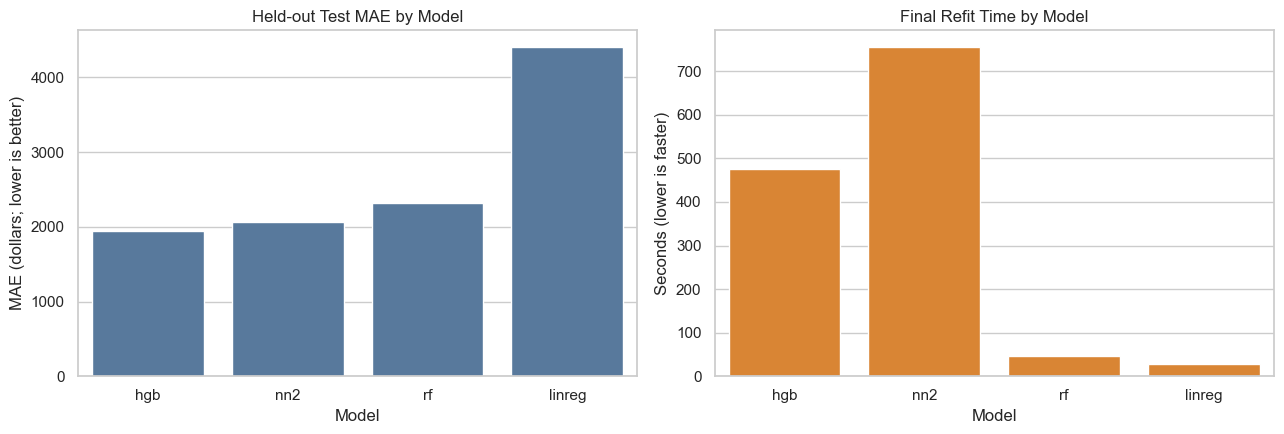

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.barplot(
    data=performance_table.reset_index(),
    x="model",
    y="test_MAE",
    ax=axes[0],
    color="#4C78A8",
)
axes[0].set_title("Held-out Test MAE by Model")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("MAE (dollars; lower is better)")

sns.barplot(
    data=performance_table.reset_index(),
    x="model",
    y="training_time_sec",
    ax=axes[1],
    color="#F58518",
)
axes[1].set_title("Final Refit Time by Model")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Seconds (lower is faster)")

plt.tight_layout()
plt.show()

## 4. Discussion

### Decision: Identify best and worst models from held-out MAE

The best model is defined as the one with the lowest test MAE because the project predicts prices in dollars and MAE directly answers how far predictions are from actual listing prices on average. The worst model is the one with the highest test MAE. R² and MAPE remain important supporting measures, so the notebook also checks whether they lead to a consistent conclusion.

The interpretation is generated from the executed results instead of assuming in advance that a nonlinear model must win. Linear Regression can struggle when depreciation, mileage, vehicle age, brand, and equipment interact nonlinearly. Random Forest can capture those interactions but may lose precision because its depth and leaf sizes are deliberately regularized. Histogram Gradient Boosting can model smooth nonlinear structure efficiently. Neural networks may perform strongly when the scaled inputs contain enough data, but their outcome depends on optimization, regularization, and architecture.

In [15]:
best_model_name = performance_table["test_MAE"].idxmin()
worst_model_name = performance_table["test_MAE"].idxmax()
best_row = performance_table.loc[best_model_name]
worst_row = performance_table.loc[worst_model_name]

print("RESULTS DISCUSSION")
print("-" * 70)
print(
    f"Best model by held-out MAE: {best_model_name}. "
    f"Its test MAE is ${best_row['test_MAE']:,.2f}, "
    f"test MAPE is {best_row['test_MAPE']:.2%}, and "
    f"test R² is {best_row['test_R2']:.4f}."
)
print(
    f"Worst model by held-out MAE: {worst_model_name}. "
    f"Its test MAE is ${worst_row['test_MAE']:,.2f}, "
    f"test MAPE is {worst_row['test_MAPE']:.2%}, and "
    f"test R² is {worst_row['test_R2']:.4f}."
)

for model_name, row in performance_table.iterrows():
    mae_gap = row["test_MAE"] - row["cv_MAE_mean"]
    r2_gap = row["cv_R2_mean"] - row["test_R2"]
    print(
        f"{model_name}: test MAE minus CV MAE = ${mae_gap:,.2f}; "
        f"CV R² minus test R² = {r2_gap:.4f}."
    )

print(
    "Small CV-to-test gaps indicate stable generalization. Large positive "
    "MAE gaps or R² drops should be discussed as possible overfitting or "
    "train/test distribution differences."
)

RESULTS DISCUSSION
----------------------------------------------------------------------
Best model by held-out MAE: hgb. Its test MAE is $1,948.35, test MAPE is 7.92%, and test R² is 0.9664.
Worst model by held-out MAE: linreg. Its test MAE is $4,409.66, test MAPE is 20.80%, and test R² is 0.8459.
hgb: test MAE minus CV MAE = $0.02; CV R² minus test R² = -0.0020.
nn2: test MAE minus CV MAE = $-70.42; CV R² minus test R² = -0.0046.
rf: test MAE minus CV MAE = $-58.53; CV R² minus test R² = -0.0054.
linreg: test MAE minus CV MAE = $7.83; CV R² minus test R² = -0.0008.
Small CV-to-test gaps indicate stable generalization. Large positive MAE gaps or R² drops should be discussed as possible overfitting or train/test distribution differences.


## 5. Export

### Decision: Save reproducible metrics and only final fitted models

The performance table is saved as `data/model_metrics.csv`. Each sklearn `best_estimator_` is saved with the Notebook 3 naming convention. Only the selected and fully refitted Keras model is saved; the two unselected architectures and temporary fold models are intentionally not exported.

A feature-list file is saved alongside the metrics. It is not a replacement for the required exports, but it records the exact predictor order needed when a saved Keras model is loaded later.

In [16]:
METRICS_PATH = DATA_DIR / "model_metrics.csv"
FEATURE_PATH = DATA_DIR / "notebook3_model_features.csv"

performance_table.to_csv(METRICS_PATH, index=True, index_label="model")
pd.DataFrame({"feature": feature_cols}).to_csv(FEATURE_PATH, index=False)

sklearn_export_names = {
    "linreg": "P1_N3_linreg.pkl",
    "rf": "P1_N3_rf.pkl",
    "hgb": "P1_N3_hgb.pkl",
}

exported_paths = [METRICS_PATH, FEATURE_PATH]

for model_name, filename in sklearn_export_names.items():
    model_path = MODELS_DIR / filename
    joblib.dump(sklearn_searches[model_name].best_estimator_, model_path)
    exported_paths.append(model_path)

keras_model_path = MODELS_DIR / f"P1_N3_{winning_architecture}.keras"
best_keras_model.save(keras_model_path)
exported_paths.append(keras_model_path)

assert all(path.exists() for path in exported_paths)
assert pd.read_csv(METRICS_PATH).shape[0] == 4

print("Exported files:")
for path in exported_paths:
    size_mb = path.stat().st_size / (1024 ** 2)
    print(f"  {path} ({size_mb:.2f} MB)")

print("\nNotebook 4 must load model_metrics.csv as its baseline table.")

Exported files:
  C:\Users\lawra\Fall 2026-2027 Semester Document\MSDS 565-01\Unit 1 - Car Sales\MSDS565-CarSales-Team1\data\model_metrics.csv (0.00 MB)
  C:\Users\lawra\Fall 2026-2027 Semester Document\MSDS 565-01\Unit 1 - Car Sales\MSDS565-CarSales-Team1\data\notebook3_model_features.csv (0.01 MB)
  C:\Users\lawra\Fall 2026-2027 Semester Document\MSDS 565-01\Unit 1 - Car Sales\MSDS565-CarSales-Team1\models\P1_N3_linreg.pkl (0.01 MB)
  C:\Users\lawra\Fall 2026-2027 Semester Document\MSDS 565-01\Unit 1 - Car Sales\MSDS565-CarSales-Team1\models\P1_N3_rf.pkl (72.44 MB)
  C:\Users\lawra\Fall 2026-2027 Semester Document\MSDS 565-01\Unit 1 - Car Sales\MSDS565-CarSales-Team1\models\P1_N3_hgb.pkl (1.78 MB)
  C:\Users\lawra\Fall 2026-2027 Semester Document\MSDS 565-01\Unit 1 - Car Sales\MSDS565-CarSales-Team1\models\P1_N3_nn2.keras (1.31 MB)

Notebook 4 must load model_metrics.csv as its baseline table.


## Final Completion Check

This audit confirms that Notebook 3 produced all required outputs: three sklearn final models, one winning Keras final model, a four-row performance table with all required metrics, and the exact reusable Notebook 2 split.

In [18]:
required_metric_columns = {
    "cv_MAE_mean",
    "cv_MAPE_mean",
    "cv_R2_mean",
    "test_MAE",
    "test_MAPE",
    "test_R2",
    "training_time_sec",
}

assert required_metric_columns.issubset(performance_table.columns)
assert set(["linreg", "rf", "hgb"]).issubset(performance_table.index)
assert winning_architecture in performance_table.index
assert len(performance_table) == 4

print("Notebook 3 completion audit passed.")
print("Review the executed tables.")

Notebook 3 completion audit passed.
Review the executed tables.
